In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import kagglehub

import warnings
warnings.filterwarnings('ignore')

In [32]:
path = kagglehub.dataset_download('santoshd3/bank-customers')

df = pd.read_csv(path + '/Churn Modeling.csv')

df_copy = df.copy()

In [33]:
df.shape

(10000, 14)

In [34]:
df.sample(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
5047,5048,15790412,Norton,471,Spain,Male,26,8,0.00,2,1,1,179655.87,0
2973,2974,15651983,Fang,591,France,Female,56,9,128882.49,1,1,1,196241.94,1
3459,3460,15754919,Nwebube,773,France,Female,40,10,0.00,2,0,1,69303.15,0
999,1000,15787772,Hansen,759,France,Female,38,1,104091.29,1,0,0,91561.91,0
7281,7282,15735572,Lawrence,629,France,Male,59,9,113657.83,1,1,1,116848.79,1
46,47,15602280,Martin,829,Germany,Female,27,9,112045.67,1,1,1,119708.21,1
8972,8973,15718780,Cox,650,Spain,Female,32,4,79450.09,1,1,1,118324.75,0
6388,6389,15582033,Manfrin,753,Germany,Male,44,3,138076.47,1,1,0,15523.09,1
6444,6445,15731412,Trevisano,693,Germany,Female,37,6,95900.04,1,1,1,38196.24,0
3059,3060,15670619,Coppin,631,France,Female,33,8,0.00,2,0,0,117374.22,0


In [35]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [37]:
df.isnull().sum().sum()

np.int64(0)

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


In [40]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df_copy = df_copy.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

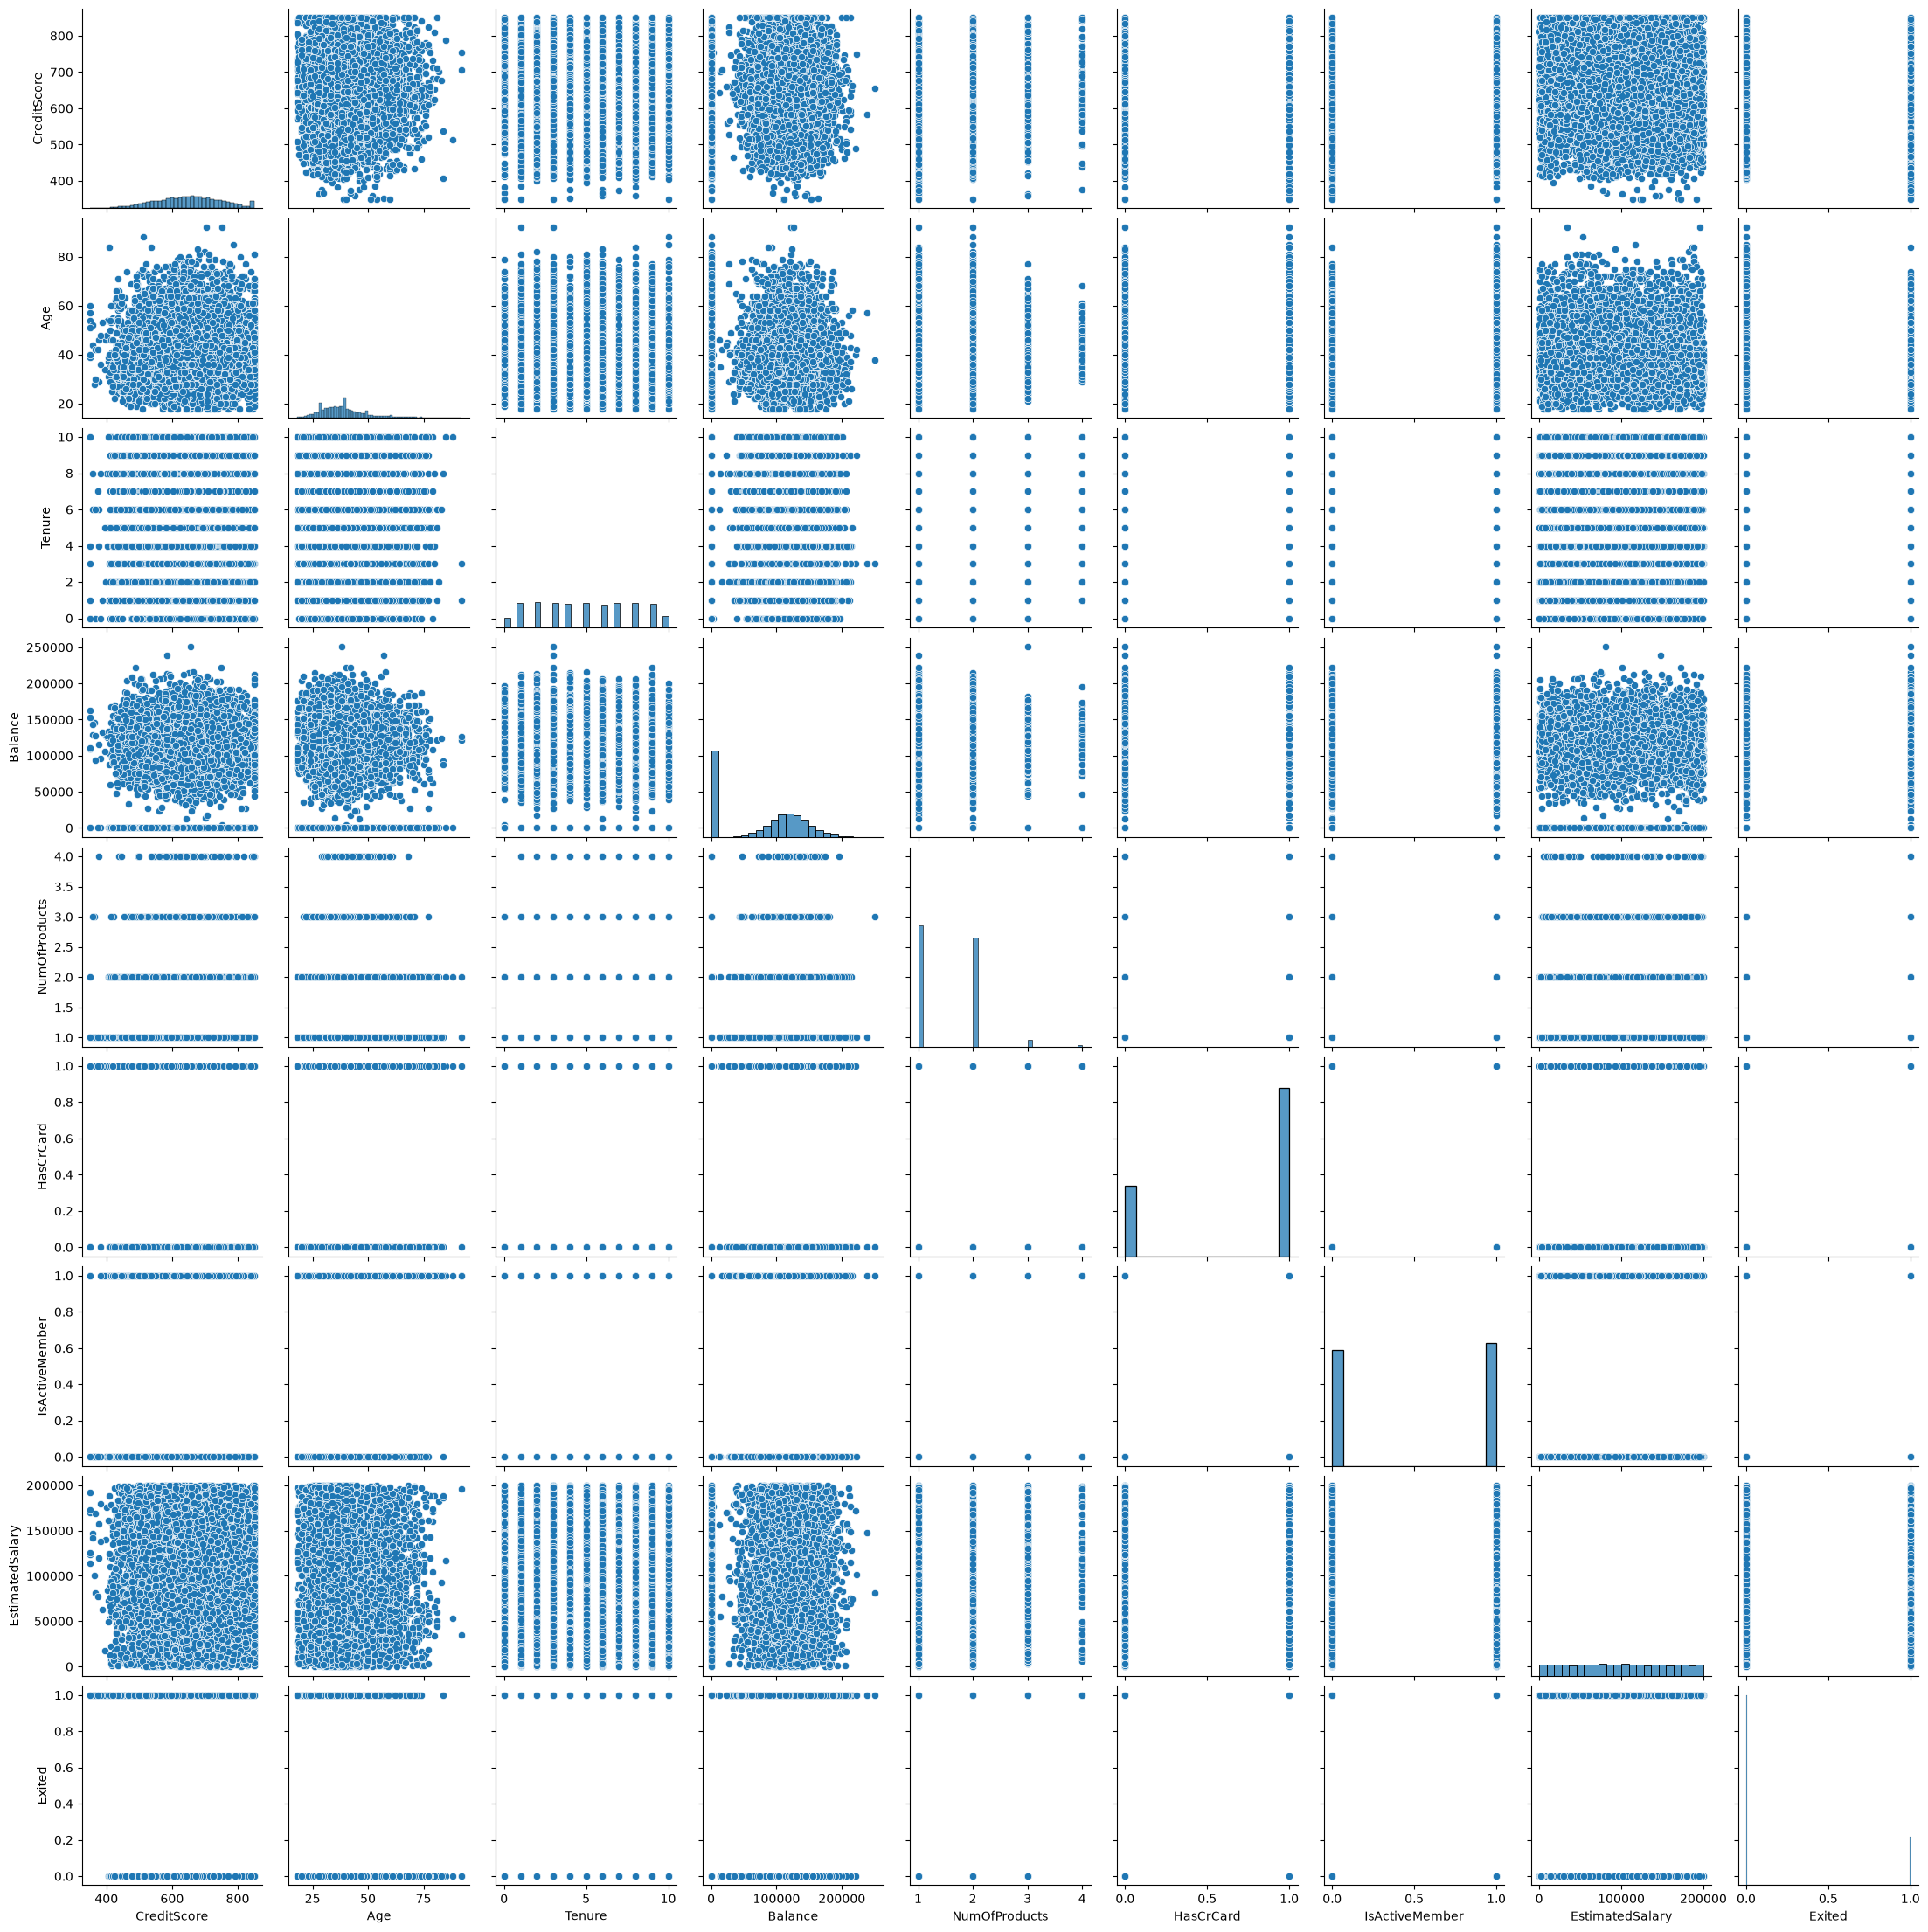

In [41]:
sns.pairplot(df) 

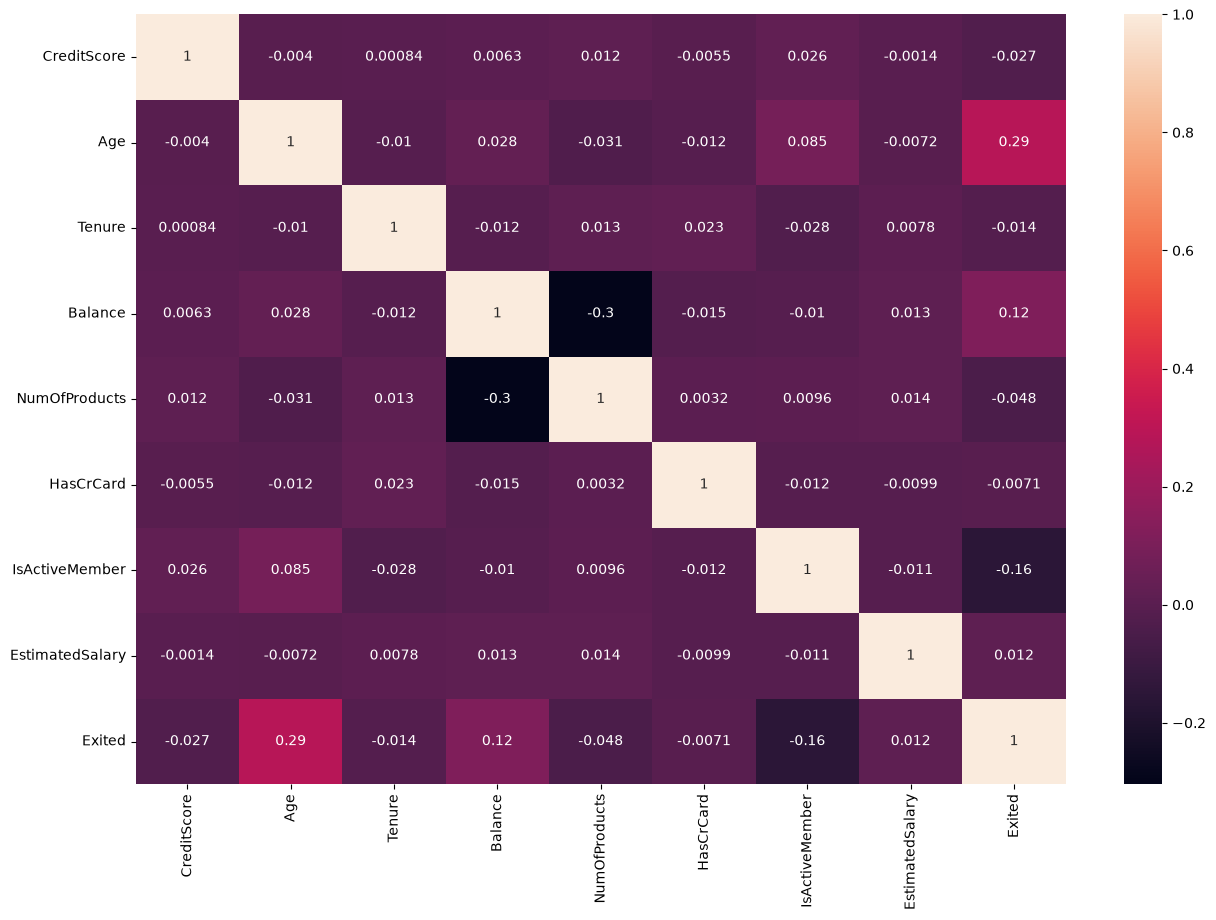

In [42]:
plt.figure(figsize=(15,10))
sns.heatmap(df.select_dtypes('number').corr(),annot=True)
plt.show()

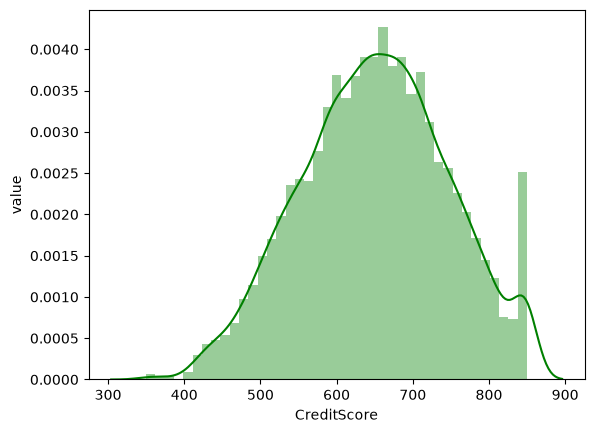

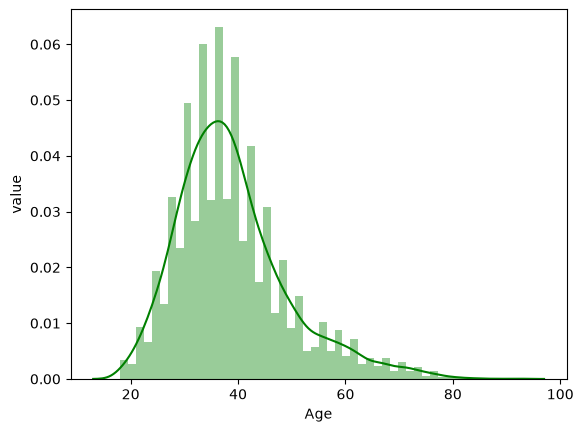

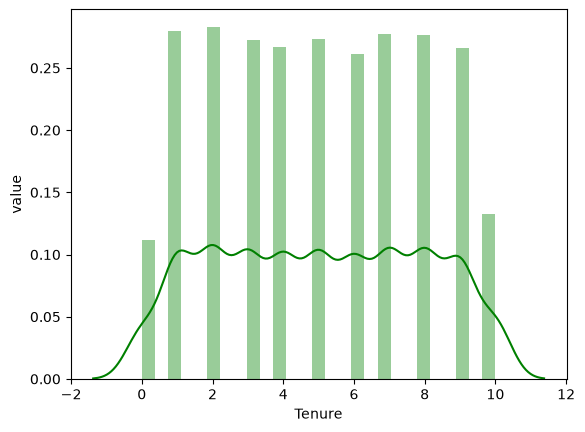

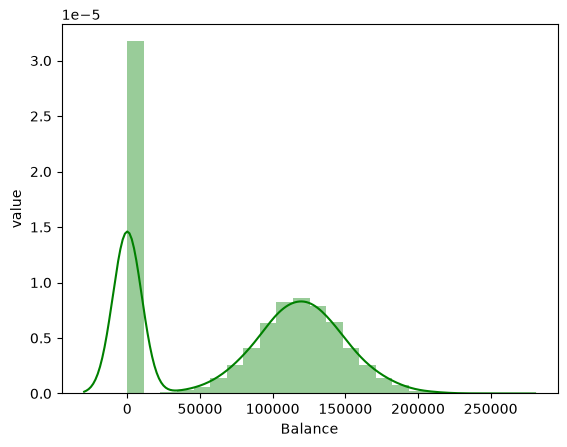

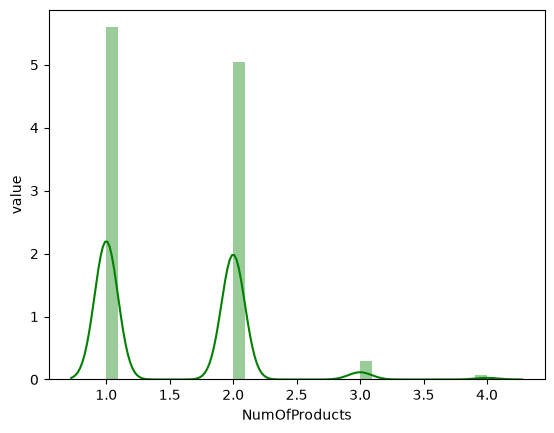

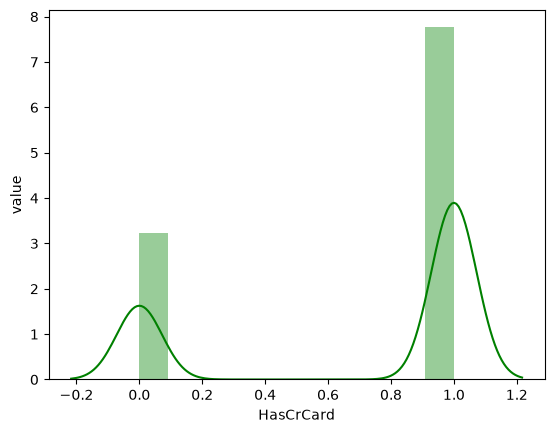

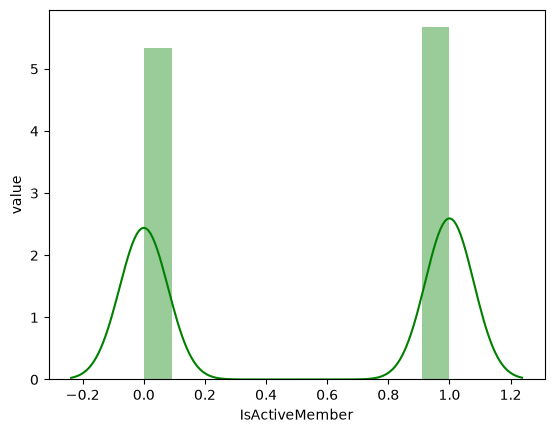

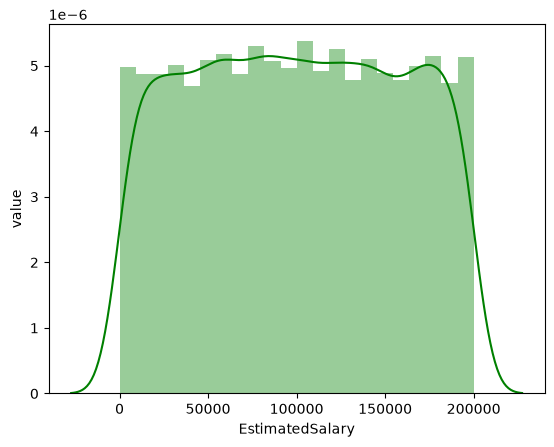

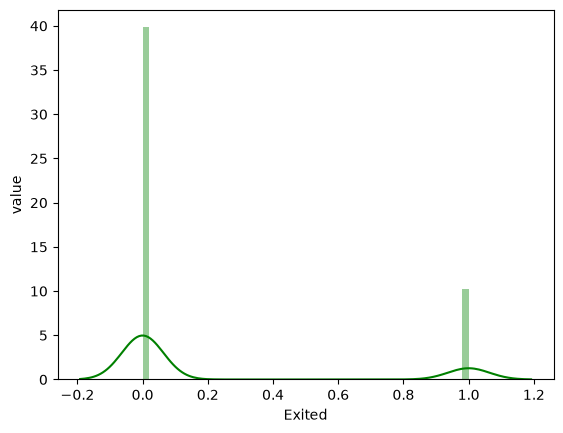

In [43]:
for i in df.select_dtypes('number').columns:
    sns.distplot(df[i],color='green')
    plt.xlabel(i)
    plt.ylabel('value')
    plt.show()

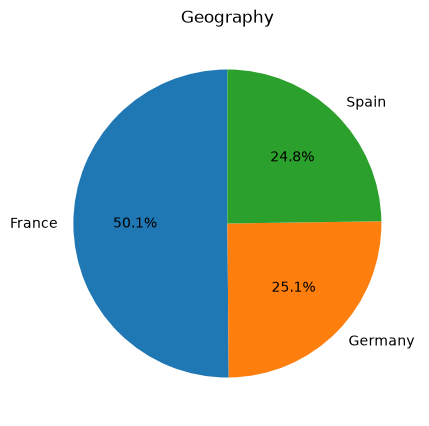

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

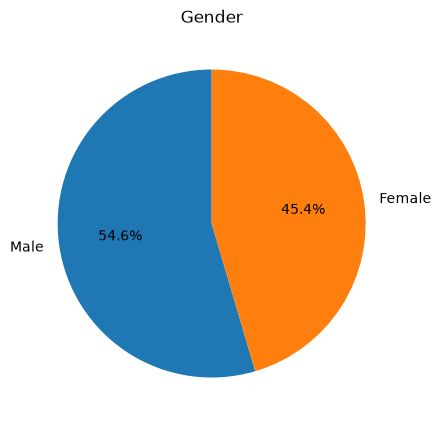

Gender
Male      5457
Female    4543
Name: count, dtype: int64

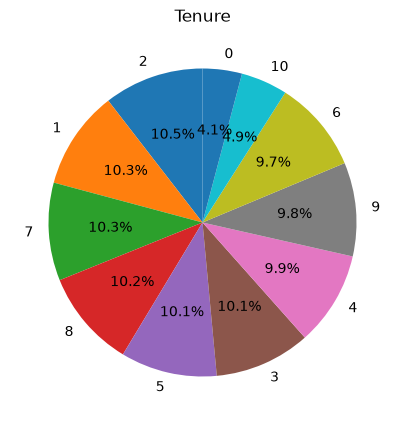

Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64

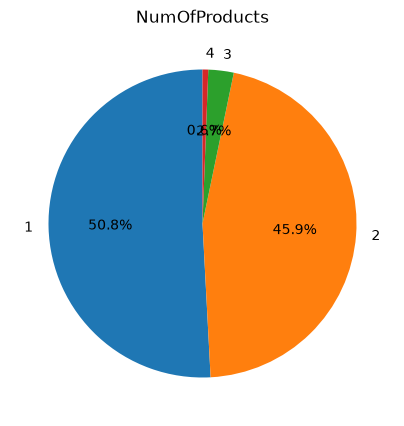

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

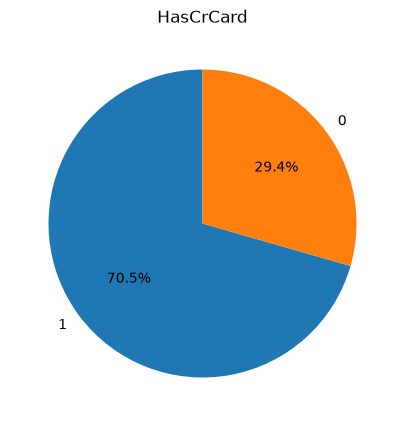

HasCrCard
1    7055
0    2945
Name: count, dtype: int64

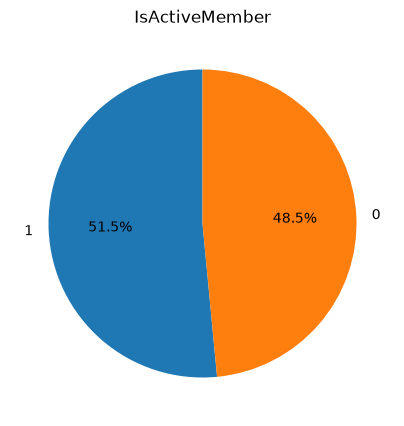

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

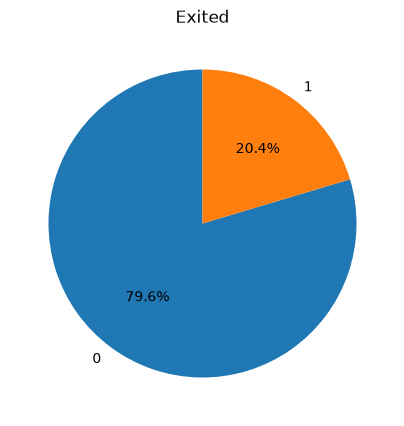

Exited
0    7963
1    2037
Name: count, dtype: int64

In [44]:
for c in ['Geography', 'Gender', 'Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']:
    plt.figure(figsize=(5,5))
    df[c].value_counts().plot(kind='pie', autopct='%.1f%%', startangle=90)
    plt.ylabel('') 
    plt.title(c)
    plt.show()
    display(df[c].value_counts())

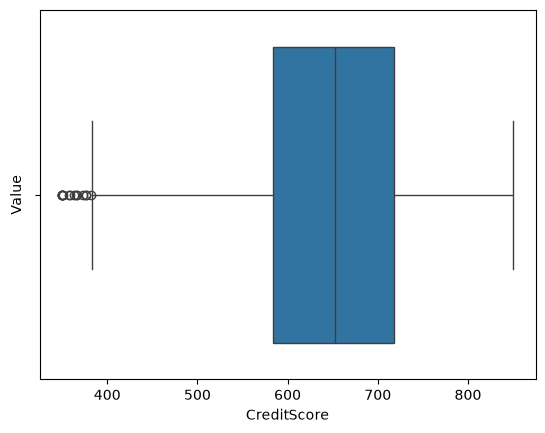

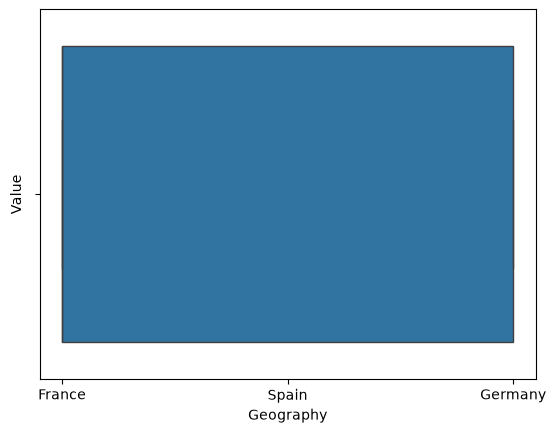

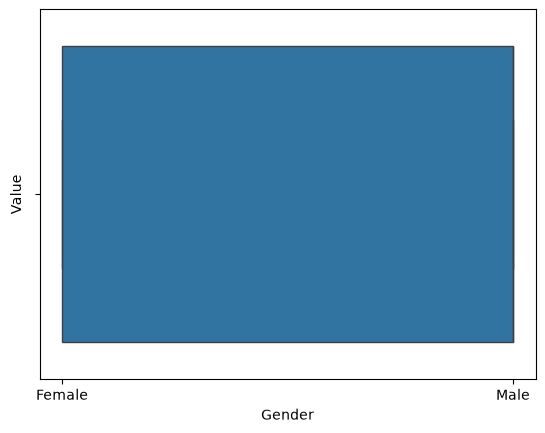

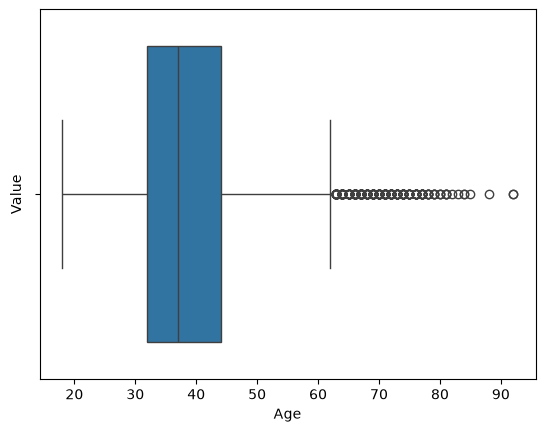

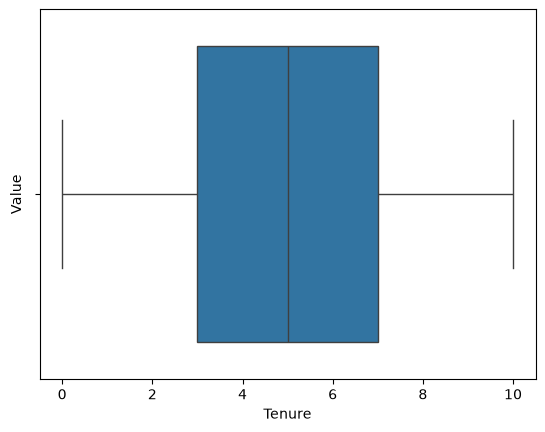

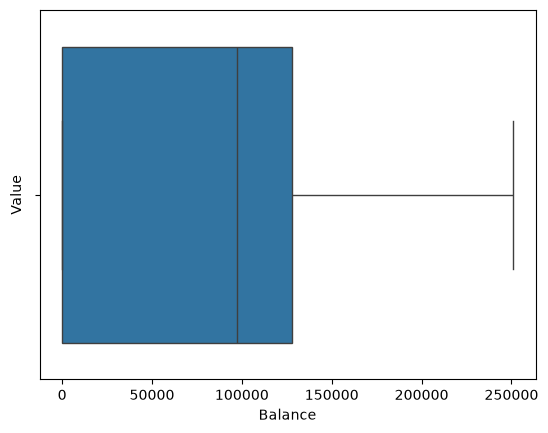

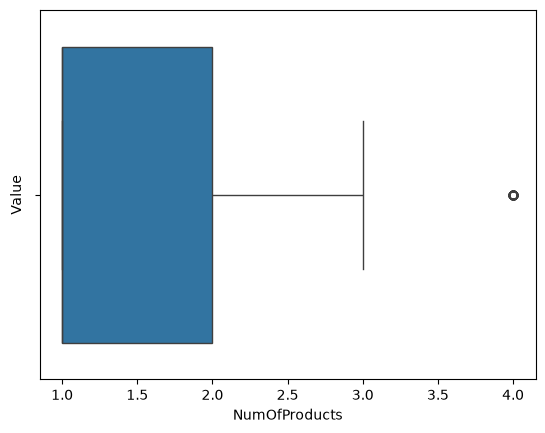

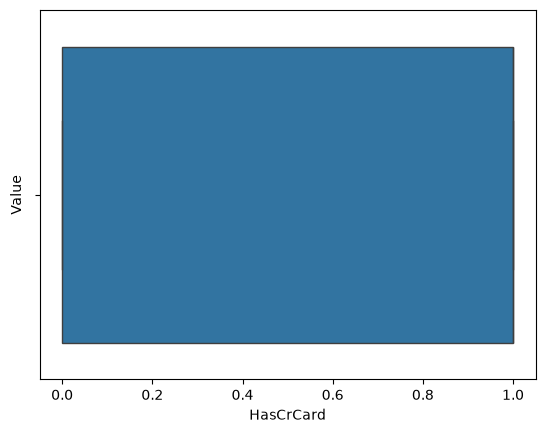

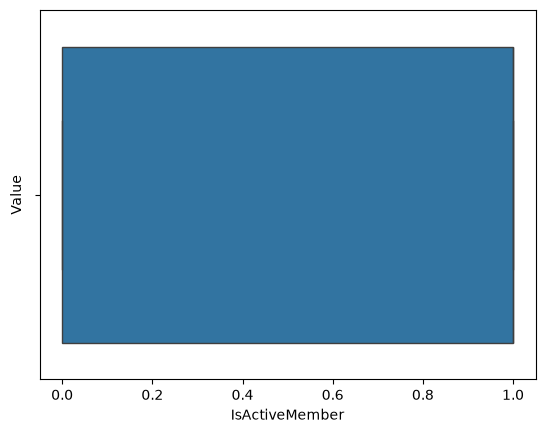

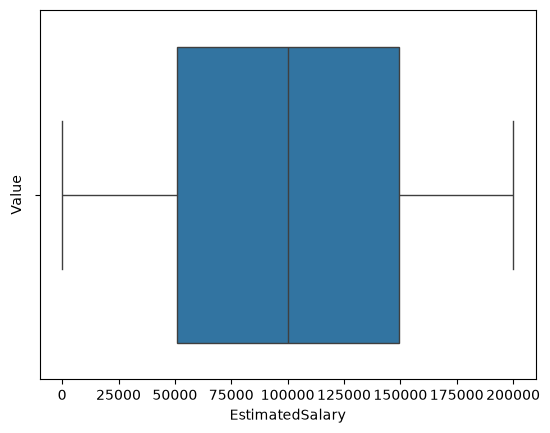

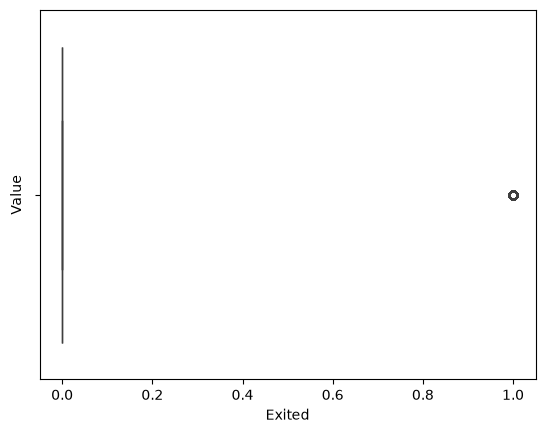

In [45]:
for c in df.columns:
    sns.boxplot(x= df[c])
    plt.xlabel(c)
    plt.ylabel('Value')
    plt.show()

In [46]:
num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Tenure', 'NumOfProducts']
cat_cols = ['Geography', 'Gender']
mapped_cat_cols = ['HasCrCard', 'IsActiveMember']

In [47]:
df[num_cols].skew()

CreditScore       -0.071607
Age                1.011320
Balance           -0.141109
EstimatedSalary    0.002085
Tenure             0.010991
NumOfProducts      0.745568
dtype: float64

In [48]:
from sklearn.preprocessing import PowerTransformer

transfomer = PowerTransformer(method='yeo-johnson', standardize= False)

df[['Age']] = transfomer.fit_transform(df[['Age']])

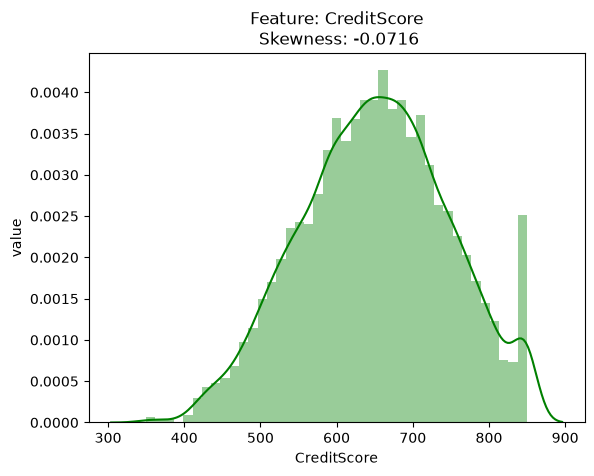

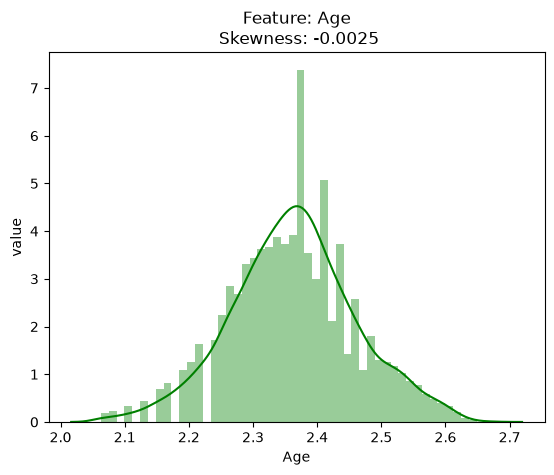

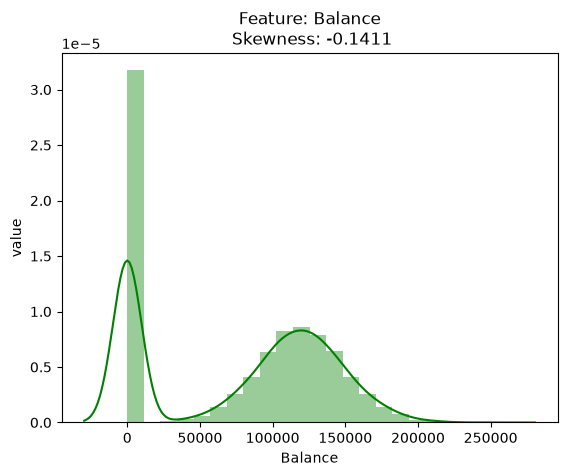

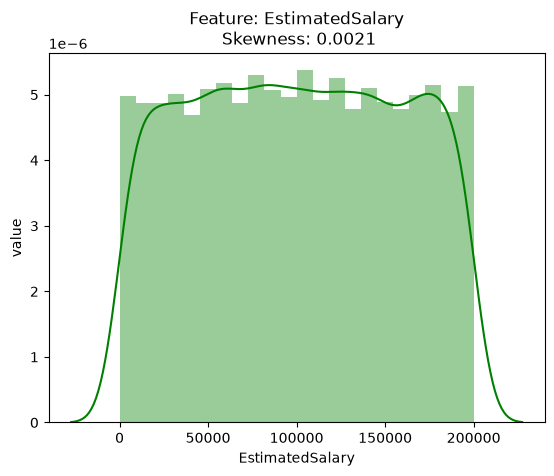

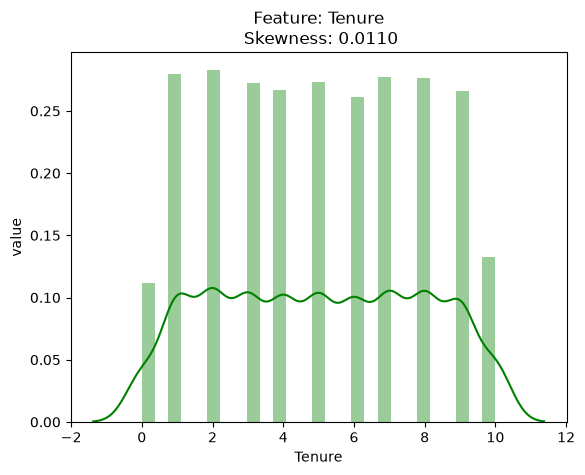

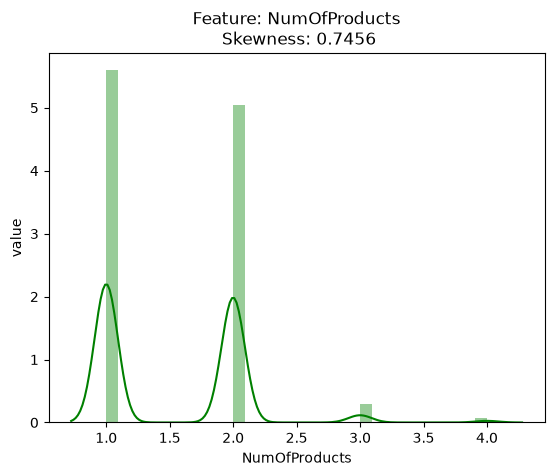

In [49]:

for i in num_cols:
    sns.distplot(df[i],color='green')
    plt.title(f'Feature: {i}\n Skewness: {df[i].skew():.4f}')
    plt.xlabel(i)
    plt.ylabel('value')
    plt.show()

In [50]:
from sklearn.model_selection import train_test_split

X = df_copy.drop(columns=['Exited'])
y = df_copy['Exited']

X_train, X_test, y_train, y_test = train_test_split(X ,y ,test_size= 0.2 ,random_state=42, stratify=y)

In [94]:
X_train_copy = X_train.copy()
y_train_copy = y_train.copy()
X_test_copy = X_test.copy()
y_test_copy = y_test.copy()

In [95]:
from collections import Counter
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTENC

fix_skew_cols = ['Age']
robust_scale_cols = ['CreditScore']
std_scale_cols = ['Balance', 'EstimatedSalary', 'Tenure', 'NumOfProducts']
cat_cols = ['Geography', 'Gender']
mapped_cat_cols = ['HasCrCard', 'IsActiveMember']


cat_cols_indices = [X_train.columns.get_loc(col) for col in cat_cols + mapped_cat_cols]
smote = SMOTENC(categorical_features= cat_cols_indices, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


for col in ['Tenure', 'NumOfProducts']:
    X_train_resampled[col] = X_train_resampled[col].round().astype(int)
    X_train_resampled[col] = X_train_resampled[col].clip(lower= X_train[col].min(), upper= X_train[col].max())

preprocessor = ColumnTransformer(transformers=[
    ('fix_skewness', PowerTransformer(method= 'yeo-johnson', standardize= True), fix_skew_cols),
    ('std_scaler', StandardScaler(), std_scale_cols),
    ('robust_scaler', RobustScaler(), robust_scale_cols),
    ('encoder', OneHotEncoder(sparse_output= False, handle_unknown='ignore', drop= 'if_binary', dtype= int), cat_cols)
],remainder= 'passthrough', verbose_feature_names_out= False)

#Without SMOTE
preprocessor.set_output(transform='pandas')
X_train_copy_final = preprocessor.fit_transform(X_train_copy)
X_test_copy_final = preprocessor.transform(X_test_copy)

preprocessor.set_output(transform='pandas')
X_train_transformed = preprocessor.fit_transform(X_train_resampled)
X_test_final = preprocessor.transform(X_test)
y_test_final = y_test
X_train_final = X_train_transformed
y_train_final = y_train_resampled

df_final = X_train_transformed.copy()
df_final['Exited'] = y_train_resampled.copy()

print('Shape: ')
display(df_final.shape)
print('Sample: ')
display(df_final.sample(10))

Shape: 


(12740, 13)

Sample: 


,Age,Balance,EstimatedSalary,Tenure,NumOfProducts,CreditScore,Geography_France,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard,IsActiveMember,Exited
9317,-0.101328,-1.348935,0.132251,0.053052,-0.728400,0.214286,1,0,0,1,1,0,1
8945,-0.206774,0.706031,-0.843839,-0.314075,-0.728400,0.357143,0,1,0,0,1,1,1
8691,0.395265,1.507231,-0.195405,-1.048328,-0.728400,0.293651,0,1,0,0,1,0,1
11909,0.489043,0.985376,-0.902575,0.053052,-0.728400,-0.412698,0,1,0,1,1,0,1
198,0.581145,-1.144421,0.971173,0.420179,-0.728400,-0.047619,0,0,1,0,0,0,1
9607,-0.424575,0.784842,-0.439750,0.420179,-0.728400,0.333333,0,1,0,0,1,0,1
1014,0.395265,1.154470,0.625909,-1.048328,-0.728400,0.928571,1,0,0,0,1,1,0
7382,-1.545616,1.128137,-1.457544,-0.681202,1.037502,0.047619,0,1,0,0,1,0,0
1646,-0.770338,0.240586,0.136818,-1.415455,-0.728400,0.007937,1,0,0,0,1,0,0
1179,-0.537159,-1.348935,-0.122734,-1.048328,1.037502,-1.896825,1,0,0,0,1,1,0


After Balancing


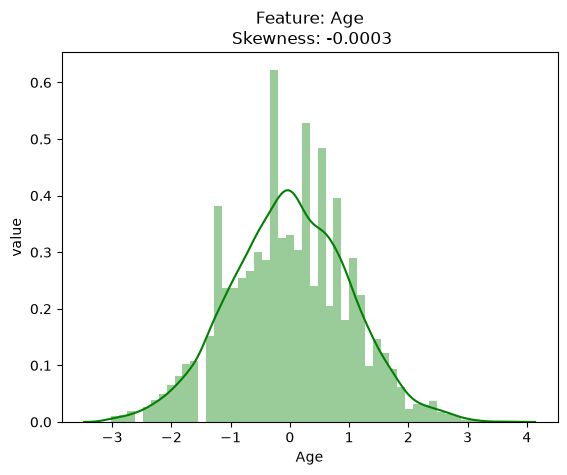

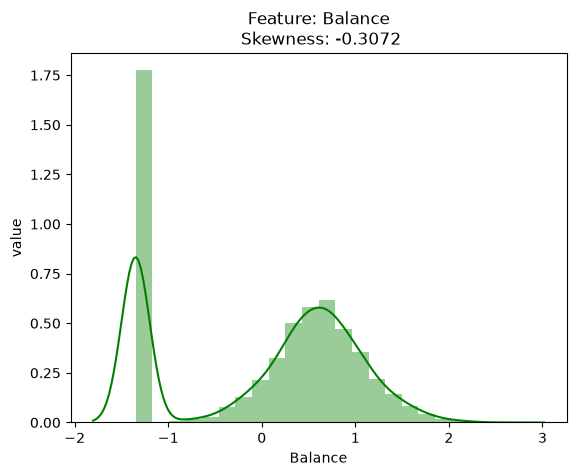

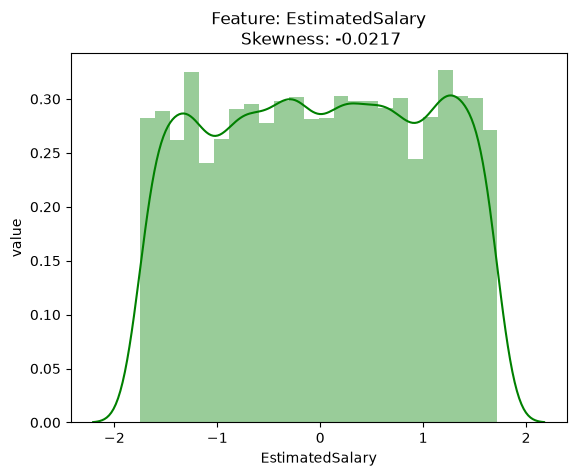

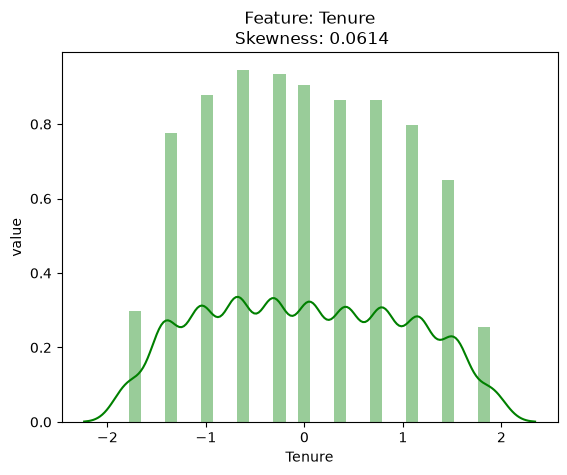

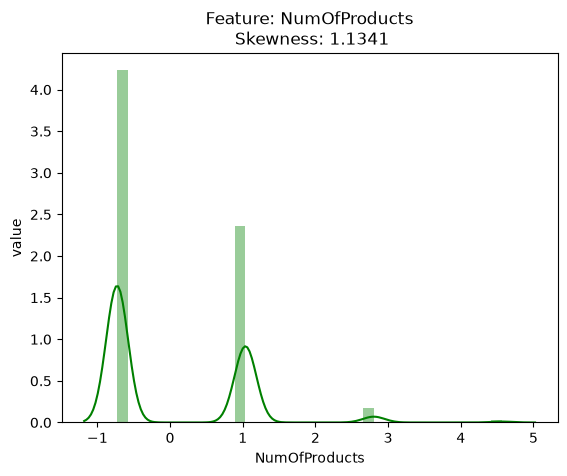

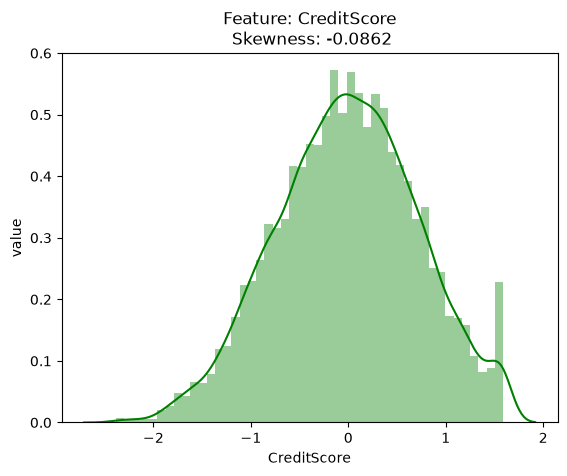

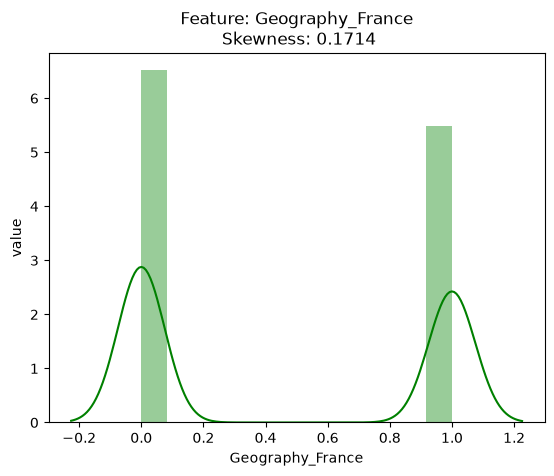

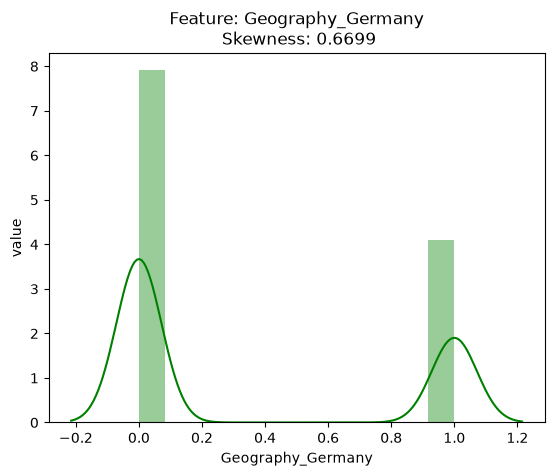

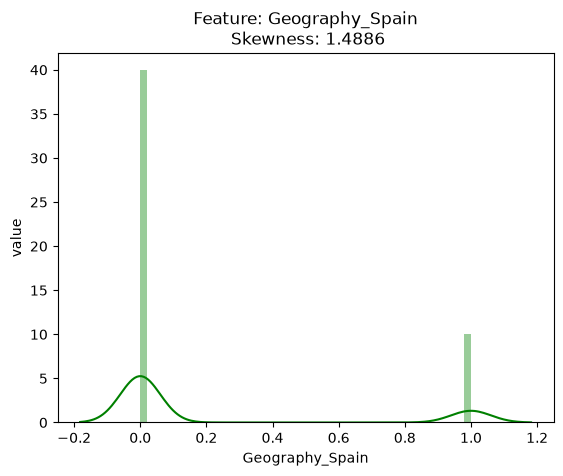

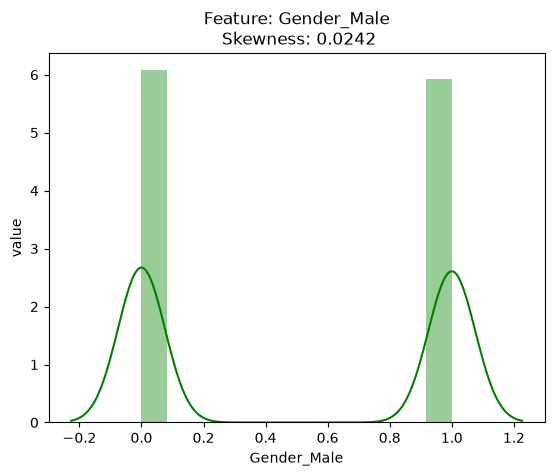

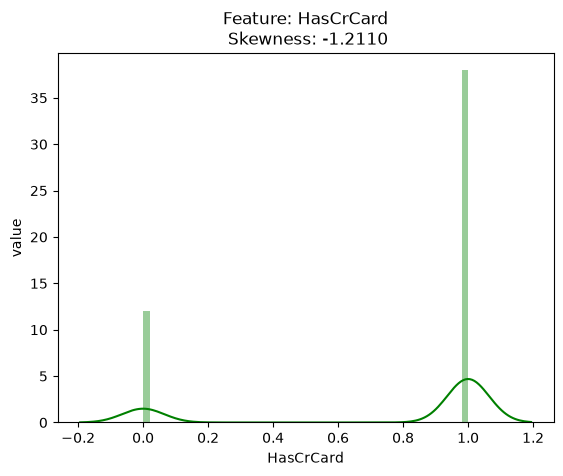

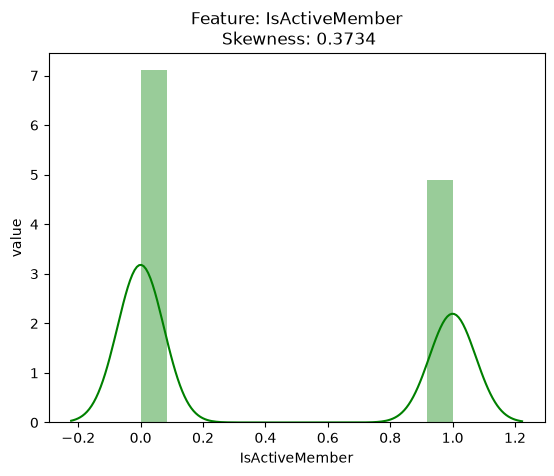

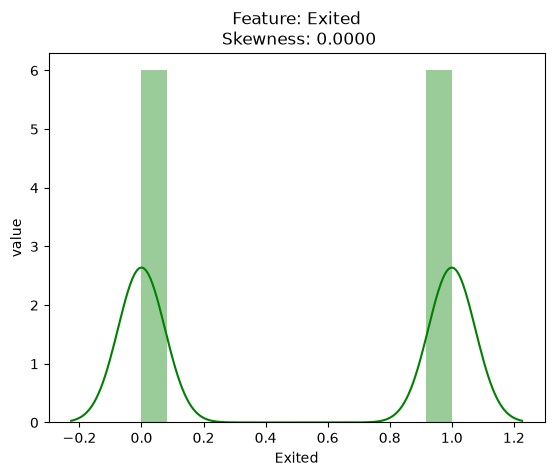

In [52]:
print('After Balancing')

for i in df_final.columns:
    sns.distplot(df_final[i],color='green')
    plt.title(f'Feature: {i}\n Skewness: {df_final[i].skew():.4f}')
    plt.xlabel(i)
    plt.ylabel('value')
    plt.show()

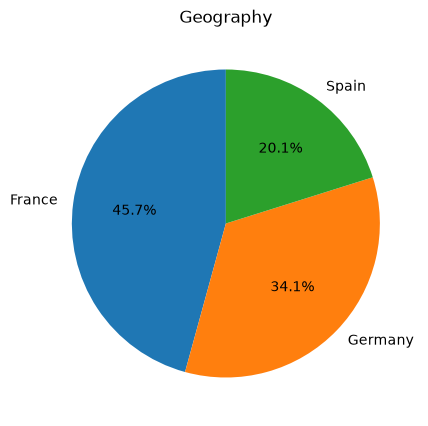

Geography
France     5826
Germany    4347
Spain      2567
Name: count, dtype: int64

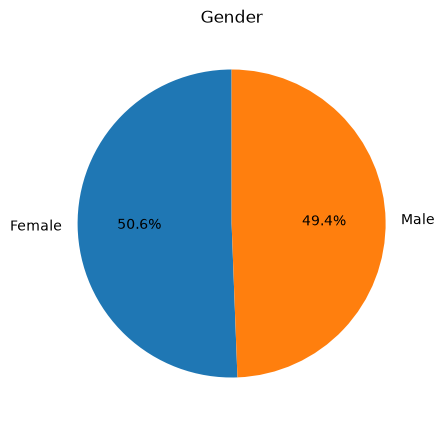

Gender
Female    6447
Male      6293
Name: count, dtype: int64

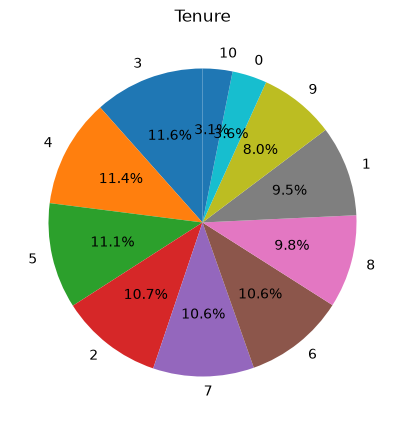

Tenure
3     1474
4     1455
5     1413
2     1367
7     1350
6     1348
8     1244
1     1212
9     1014
0      464
10     399
Name: count, dtype: int64

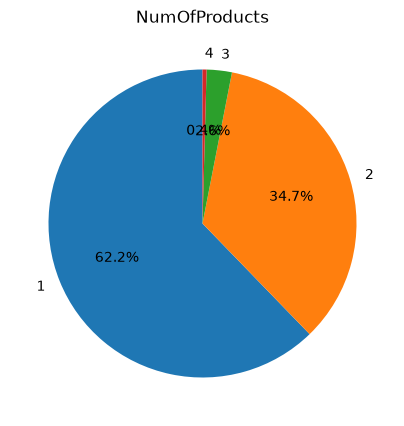

NumOfProducts
1    7930
2    4419
3     337
4      54
Name: count, dtype: int64

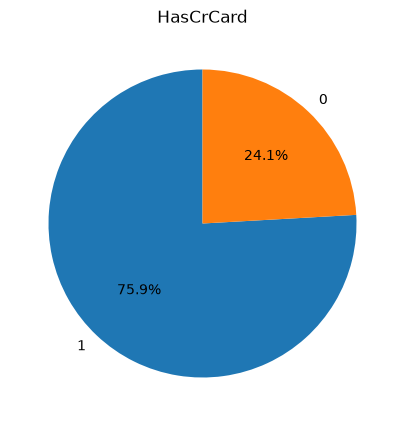

HasCrCard
1    9669
0    3071
Name: count, dtype: int64

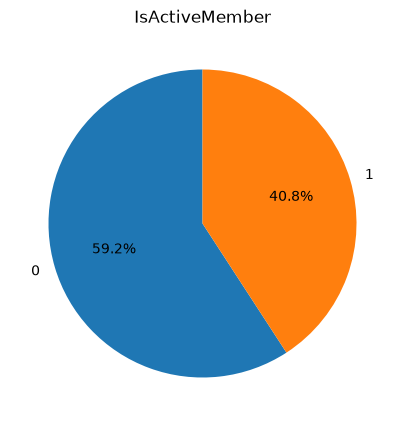

IsActiveMember
0    7539
1    5201
Name: count, dtype: int64

In [53]:
for c in X_train_resampled.columns:
    if X_train_resampled[c].nunique() < 15:
        plt.figure(figsize=(5,5))
        X_train_resampled[c].value_counts().plot(kind='pie', autopct='%.1f%%', startangle=90)
        plt.ylabel('') 
        plt.title(c)
        plt.show()
        display(X_train_resampled[c].value_counts())

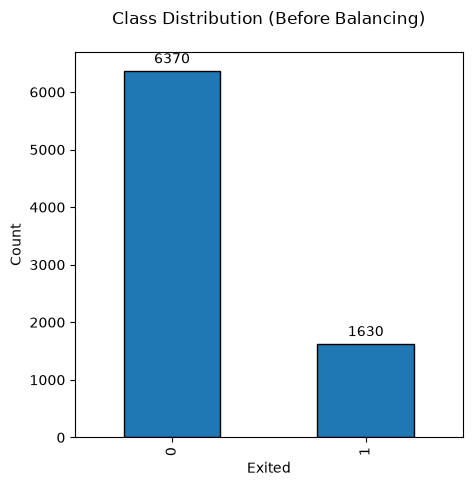

Exited
0    6370
1    1630
Name: count, dtype: int64

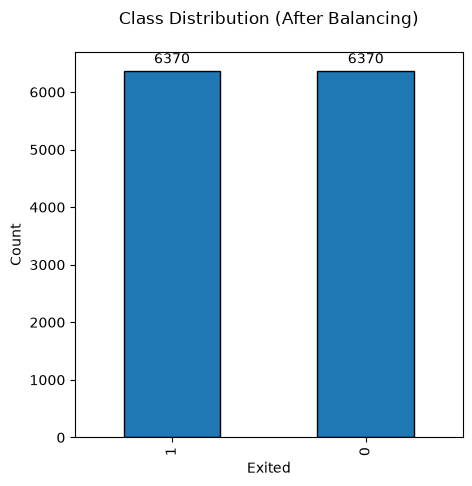

Exited
1    6370
0    6370
Name: count, dtype: int64

In [54]:
li = {'Before Balancing':y_train, 'After Balancing':y_train_resampled}
for i, s in li.items():
    plt.figure(figsize=(5,5))
    ax = s.value_counts().plot(kind='bar', edgecolor='black')
    plt.ylabel('Count')
    ax.bar_label(ax.containers[0], padding=3)
    plt.title(f'Class Distribution ({i})\n')
    plt.show()
    display(s.value_counts())

In [55]:
X_train_transformed.shape

(12740, 12)

In [ ]:
import keras
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
callback=EarlyStopping(monitor='val_accuracy',min_delta=0.00001,patience=20,verbose=1,mode='auto', restore_best_weights=True)

In [ ]:
model= keras.Sequential()
model.add(Dense(64,activation='relu', input_shape= (X_train_copy_final.shape[1],), kernel_initializer= 'he_normal'))
model.add(Dense(16,activation='relu', kernel_initializer= 'he_normal'))
model.add(Dropout(0.15))
model.add(Dense(1,activation='sigmoid', kernel_initializer= 'glorot_uniform'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
history=model.fit(X_train_copy_final,y_train_copy,validation_data=(X_test_copy_final,y_test_copy),epochs=50, batch_size=32,callbacks=callback)

Epoch 1/50


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7678 - loss: 0.5208 - val_accuracy: 0.8195 - val_loss: 0.4170
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8249 - loss: 0.4130 - val_accuracy: 0.8405 - val_loss: 0.3785
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8367 - loss: 0.3845 - val_accuracy: 0.8555 - val_loss: 0.3624
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8415 - loss: 0.3732 - val_accuracy: 0.8560 - val_loss: 0.3578
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8443 - loss: 0.3691 - val_accuracy: 0.8540 - val_loss: 0.3524
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8469 - loss: 0.3637 - val_accuracy: 0.8570 - val_loss: 0.3514
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8480 - loss: 0.3573 - val_accuracy: 0.8540 - val_loss: 0.3519
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8525 - loss: 0.3554 - val_accuracy: 0.8550 - val_